In [1]:
atomstring = '''
Fe -0.64147387529051 0.51990405379180 0.11450483185168
O 0.33915564253394 2.18819453520299 -0.84159903476570
H 0.65823736209818 2.99799985286513 -0.40575899522591
O -1.29914529040912 -0.20924466129350 -1.80322550106302
H -2.11419692217693 0.03267722517314 -2.27701147100162
O 0.01237770373627 1.24396717111997 2.03533113813669
H 0.83097217272839 1.00756306178418 2.50577204385612
O -1.62284672685044 -1.15048542622041 1.07007991103536
H -1.94592790838151 -1.95766677806096 0.63237073377438
O -2.41866907277644 1.66373032346654 0.25658821238371
H -2.55381601393967 2.56024091790599 -0.09930153080408
O 1.13404022498401 -0.62623224778001 -0.02436092147139
H 1.26370551457750 -1.52400168391753 0.33034524187694
H -3.28110369794222 1.35873477131317 0.59094893393907
H -0.81032015579443 -0.82248643308581 -2.37966496653734
H 1.99795010138314 -0.32692539271158 -0.36001715946551
H 0.57998322602479 2.26642229799559 -1.78148703231078
H -0.47668197075682 1.85673194452426 2.61208351578631
H -1.85653031374812 -1.23356353207299 2.011352050005
'''

In [14]:
import numpy as np
from pyscf import gto, scf, mp, cc

mol = gto.M(atom = atomstring,
            basis = {
                'default': 'cc-pvdz-dk',
                'Fe': 'cc-pvtz-dk'
                },
            verbose = 4,
            unit = 'angstrom',
            symmetry = 0,
            charge = 2,
            spin = 4,
            max_memory = 20000,
            )

mf = scf.UHF(mol).density_fit()
mf = mf.x2c()
dm0 = mf.from_chk('./hs_tdz_mf.chk')
# mf.init_guess = 'chk'
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)

stable = False
for i in range(10):
    print(f'mf stability test {i+1}')
    if not stable:
        mo_i, _, stable,_ = mf.stability(return_status=True)
        dm = mf.make_rdm1(mo_i,mf.mo_occ)
        mf = mf.newton()
        mf.kernel(dm0=dm)
    elif stable:
        print(f'mf energy: {mf.e_tot}, stability {stable}')
        break

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sun Aug 16 16:55:18 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 19
[INPUT] num. electrons = 84
[INPUT] charge = 2
[INPUT] spin (= nelec alpha-beta = 2S) = 4
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z  

ecp = {}
CPU time:      6581.68




******** <class 'pyscf.soscf.newton_ah.SecondOrdersfX2C1eDFUHF'> ********
method = SecondOrdersfX2C1eDFUHF
initial guess = minao
damping factor = 0
level_shift factor = 0.5
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 100
direct_scf = False
chkfile to save SCF result = /tmp/tmpdgdsvy9q
max_memory 20000 MB (current use 2300 MB)
number electrons alpha = 44  beta = 40


******** <class 'pyscf.x2c.sfx2c1e.SpinFreeX2CHelper'> ********
approx = 1e
xuncontract = 1
******** <class 'pyscf.x2c.sfx2c1e.sfX2C1eDFUHF'> Newton solver flags ********
SCF tol = 1e-09
conv_tol_grad = None
max. SCF cycles = 100
direct_scf = False
chkfile to save SCF result = /tmp/tmpdgdsvy9q
max_cycle_inner = 12
max_stepsize = 0.05
ah_start_tol = 1e+09
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_start_cycle = 1
ah_max_cycle = 40
ah_grad_trust_region = 2.5
kf_interva

In [15]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (201, 201)
frozen orbitals 11
max_memory 20000 MB (current use 2084 MB)
E(DFUMP2) = -1729.28125531906  E_corr = -1.73839072850312
E(SCS-DFUMP2) = -1729.20156035405  E_corr = -1.6586957634973
E_corr(same-spin) = -0.493122820045894
E_corr(oppo-spin) = -1.24526790845723
-1.7383907285031213


In [4]:
from pyscf.data import elements
from pyscf.lno import lnoccsd, ulnoccsd, tools
from pyscf.lno.tools import autofrag_iao
from pyscf import lo
from afqmc.lno_afqmc import tools as lnoafqmc_tools

In [5]:
def name_fragments(frag_atmlist, elements, sep=""):
    """
    Build a name for each fragment by tagging every atom with its
    element symbol and its original index.

    frag_atmlist : list of lists of atom indices
    elements     : list mapping atom index -> element symbol
    sep          : string placed between atoms in a fragment name
    """
    return [sep.join(f"{elements[i]}{i}" for i in frag)
            for frag in frag_atmlist]

In [11]:
from pyscf import lo

def riao_fragment(mf, nfrozen, frag_type='atom', more_loc=None):
    # IAO localization
    mol = mf.mol
    s1e = mf.get_ovlp()
    moliao = lo.iao.reference_mol(mol)
    nocc = np.count_nonzero(mf.mo_occ)
    orbocc = mf.mo_coeff[:,nfrozen:nocc]
    lo_coeff = lo.iao.iao(mol, orbocc)
    lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)

    if frag_type == 'atom':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=False)
    elif frag_type == 'h2heavy':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=True)
    else:
        raise ValueError(f'Unsupported fragment type {str(frag_type)}')

    if more_loc is None:
        frag_list = autofrag_iao(moliao, 'atom', frag_atmlist)
    elif more_loc == 'boys':
        lo_coeff = lo.Boys(mol).kernel(lo_coeff)
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    elif more_loc == 'pm':
        lo_coeff = lo.PM(mol).kernel(lo_coeff)
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    else:
        raise ValueError(f'Unsupported lo type {str(more_loc)}')

    frag_name = name_fragments(frag_atmlist, moliao.elements, sep="")
    
    return lo_coeff, frag_list, frag_name

def uiao_fragment(mf, nfrozen, frag_type='atom', more_loc=None):
    # IAO localization
    mol = mf.mol
    s1e = mf.get_ovlp()
    moliao = lo.iao.reference_mol(mol)
    nocca = np.count_nonzero(mf.mo_occ[0])
    noccb = np.count_nonzero(mf.mo_occ[1])
    orbocc_a = mf.mo_coeff[0][:,nfrozen:nocca]
    orbocc_b = mf.mo_coeff[1][:,nfrozen:noccb]
    lo_coeff_a = lo.iao.iao(mol, orbocc_a)
    lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
    lo_coeff_b = lo.iao.iao(mol, orbocc_b)
    lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)

    if frag_type == 'atom':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=False)
    elif frag_type == 'h2heavy':
        frag_atmlist = tools.autofrag_atom(moliao, H2heavy=True)
    else:
        raise ValueError(f'Unsupported fragment type {str(frag_type)}')

    if more_loc is None:
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = autofrag_iao(moliao, 'atom', frag_atmlist)
        frag_list = [[i,i] for i in frag_list]
    elif more_loc == 'boys':
        lo_coeff_a = lo.Boys(mol).kernel(lo_coeff_a)
        lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
        lo_coeff_b = lo.Boys(mol).kernel(lo_coeff_b)
        lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    elif more_loc == 'pm':
        lo_coeff_a = lo.PM(mol).kernel(lo_coeff_a)
        lo_coeff_a = lo.orth.vec_lowdin(lo_coeff_a, s1e)
        lo_coeff_b = lo.PM(mol).kernel(lo_coeff_b)
        lo_coeff_b = lo.orth.vec_lowdin(lo_coeff_b, s1e)
        lo_coeff = [lo_coeff_a, lo_coeff_b]
        frag_list = tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
    else:
        raise ValueError(f'Unsupported lo type {str(more_loc)}')

    frag_name = name_fragments(frag_atmlist, moliao.elements, sep="")

    return lo_coeff, frag_list, frag_name

def iao_fragment(mf, nfrozen=None, frag_type='atom', more_loc=None):
    if nfrozen is None:
        nfrozen = elements.chemcore(mol)

    if isinstance(mf, scf.rhf.RHF):
        return riao_fragment(mf, nfrozen, frag_type, more_loc)

    elif isinstance(mf, scf.uhf.UHF):
        return uiao_fragment(mf, nfrozen, frag_type, more_loc)

In [7]:
from afqmc.lno_afqmc import lno_afqmc
import lno_tools
from jax import random

def run_lno(mf,
            lo_coeff, 
            frag_list,
            frag_name,
            nfrozen = 0,
            lno_thresh = 1e-6,
            qmc_options = {}, 
            chol_cut = 1e-5, 
            target_qmc_err = 1e-3, 
            run_frag = None, 
            run_ccsd = False,
            run_qmc = False,
            ):

    print("\n ******* LNO-CALCULATION ******* \n")

    lnoafqmc_tools.check_span(mf, lo_coeff, nfrozen, thresh=1e-10)

    if isinstance(mf, scf.rhf.RHF):
        spin_type = "restricted"
        mlno = lnoccsd.LNOCCSD(mf, lo_coeff, frag_list, frozen=nfrozen).set(verbose=mf.verbose)
    elif isinstance(mf, scf.uhf.UHF):
        spin_type = "unrestricted"
        mlno = ulnoccsd.ULNOCCSD(mf, lo_coeff, frag_list, frozen=nfrozen).set(verbose=mf.verbose)
    else:
        raise TypeError(f'unsupported mean-field type: {type(mf)}')

    if isinstance(lno_thresh, float):
        mlno.lno_thresh = [lno_thresh*10, lno_thresh]
    elif isinstance(lno_thresh, (list, tuple)):
        assert len(lno_thresh) == 2
        mlno.lno_thresh = [lno_thresh[0], lno_thresh[1]]

    lno_thresh = mlno.lno_thresh
    print(f"LNO THRESHOLD = {mlno.lno_thresh}")
    lno_type = ['1h','1h']
    eris = mlno.ao2mo()

    nfrag_tot = len(frag_list)
    if run_frag is None:
        run_frag = range(nfrag_tot)

    frag_list = [frag_list[i] for i in run_frag]
    frag_name = [frag_name[i] for i in run_frag]
    nfrag_run = len(frag_list)

    lno_pct_occ = [None, None]
    lno_norb = [[None,None]] * nfrag_tot

    las_size = [None]*nfrag_run
    lno_emp = np.zeros(nfrag_run, dtype='float64')
    lno_ecc  = np.zeros(nfrag_run, dtype='float64')
    lno_eqmc  = np.zeros(nfrag_run, dtype='float64')
    lno_eqmc_err  = np.zeros(nfrag_run, dtype='float64')


    seeds = random.randint(random.PRNGKey(qmc_options["seed"]),
                           shape=(nfrag_tot,), 
                           minval=0, 
                           maxval=100*nfrag_tot
                           )
    
    qmc_options["max_error"] = target_qmc_err / np.sqrt(nfrag_tot)

    # Loop over fragment
    for ifrag, frag_idx in enumerate(run_frag):
        
        loidx = frag_list[ifrag]

        print("\n")
        width = 80
        msg = f" {spin_type} LNO-FRAGMENT {frag_idx+1}/({nfrag_run},{nfrag_tot}) "
        print(msg.center(width, '='))
        print(f"Fragment Name {frag_name[ifrag]}")

        orbloc, lno_param \
            = lno_tools.get_lnoparam(mlno, lo_coeff, lno_thresh, lno_pct_occ, lno_norb, loidx, ifrag)

        lno_coeff, lno_frozen, uocc_loc, _ \
                    = mlno.make_las(eris, orbloc, lno_type, lno_param)
        
        if isinstance(mlno._scf, scf.rhf.RHF):
            lno_frozen, maskact \
                = lnoccsd.get_maskact(lno_frozen, mlno.mo_occ.size)
        elif isinstance(mlno._scf, scf.uhf.UHF):
            lno_frozen, maskact \
                = ulnoccsd.get_maskact(lno_frozen, [mlno.mo_occ[0].size, mlno.mo_occ[1].size])
        else:
            raise TypeError(f'unsupported mean-field type: {type(mlno._scf)}')

        _, nlno = lnoafqmc_tools.split_lno(mlno, lno_coeff, lno_frozen)

        eorb_mp = lno_tools.lnomp2_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)

        if run_ccsd:
            eorb_cc, t1, t2 = \
                lno_tools.lnoccsd_kernel(mlno, lno_coeff, lno_frozen, uocc_loc, maskact, verbose=4)
        else: eorb_cc = 0.0

        if run_qmc:
            eorb_qmc, eorb_qmc_err \
                = lno_afqmc.lnoafqmc_kernel(
                    mlno, lno_coeff, uocc_loc, lno_frozen, t1, t2, 
                    chol_cut, frag_idx, seeds, qmc_options)
            
        else: eorb_qmc = 0.0; eorb_qmc_err = 0.0

        print(f'LNO-Active Space Size     {nlno}')
        print(f'LNO-MP2 Orbital Energy    {eorb_mp:.8f}')
        print(f'LNO-CCSD Orbital Energy   {eorb_cc:.8f}')
        print(fr'LNO-AFQMC Orbital Energy  {eorb_qmc:.5f} {eorb_qmc_err:.5f}')

        las_size[ifrag] = nlno
        lno_emp[ifrag] = eorb_mp
        lno_ecc[ifrag] = eorb_cc
        lno_eqmc[ifrag] = eorb_qmc
        lno_eqmc_err[ifrag] = eorb_qmc_err

        qmc_err = np.sqrt(np.sum(np.array(lno_eqmc_err)**2))

    return np.array(las_size).max(), sum(lno_emp), sum(lno_ecc), sum(lno_eqmc), qmc_err

In [16]:
options = {
           'eql_time': 10,
           'n_prop_steps': 50,
           'n_blocks': 100,
           'n_walkers': 100,
           'mix_precision': False,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }

threshs = [3e-5,1e-5,3e-6,1e-6,3e-7]

iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc=None)

las1 = np.zeros(len(threshs))
elnomp1 = np.zeros(len(threshs))
elnocc1 = np.zeros(len(threshs))
elnoqmc1 = np.zeros(len(threshs))
elnoqmc_err1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las1[i], elnomp1[i], elnocc1[i], elnoqmc1[i], elnoqmc_err1[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.00030000000000000003, 3e-05]


====================== unrestricted LNO-FRAGMENT 1/(7,7) =======================
Fragment Name Fe0
LO occ proj: 10 active | 5 standby | 18 orthogonal
LO occ proj: 6 active | 8 standby | 15 orthogonal
nfrozen occupied orbitals:  [11, 11]
nactive occupied orbitals:  [33, 29]
nactive virtual orbitals:   [102, 104]
nfrozen virtual orbitals:   [66, 68]

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

Init t2, MP2 energy = -1.59403111609539
LNO-Active Space Size     [135, 133]
LNO-MP2 Orbital Energy    -0.47892367
LNO-CCSD Orbital Energy   0.00000000
LNO-AFQMC Orbital Energy  0.00000 0.00000


====================== unrestricted LNO-FRAGMENT 2/(7,7) =======================
Fragment Name O1

[135. 153. 185. 195. 201.]
[-1.71326343 -1.72738173 -1.73482771 -1.73695621 -1.73807563]


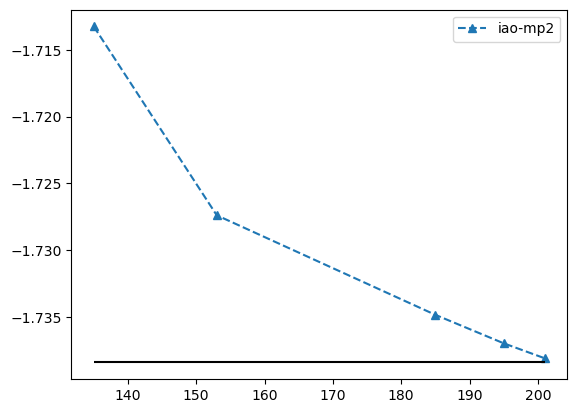

In [17]:
emp2_ref = mymp.e_corr
print(las1)
print(elnomp1)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="iao-mp2")
plt.hlines(emp2_ref, xmin=min(las1), xmax=max(las1), colors='k')
plt.legend()
plt.show()

In [18]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc='pm')

las2 = np.zeros(len(threshs))
elnomp2 = np.zeros(len(threshs))
elnocc2 = np.zeros(len(threshs))
elnoqmc2 = np.zeros(len(threshs))
elnoqmc_err2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las2[i], elnomp2[i], elnocc2[i], elnoqmc2[i], elnoqmc_err2[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )



******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
pop_method = meta_lowdin
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 56.591771433629  delta_f= 56.5918  |g|= 0.0203051  4 KF 16 Hx
macro= 2  f(x)= 56.593343020533  delta_f= 0.00157159  |g|= 0.00856586  5 KF 29 Hx
macro= 3  f(x)= 56.593366991669  delta_f= 2.39711e-05  |g|= 0.00117108  6 KF 33 Hx
macro= 4  f(x)= 56.59336843673  delta_f= 1.44506e-06  |g|= 0.00106313  4 KF 27 Hx
macro= 5  f(x)= 56.593368997759  delta_f= 5.6103e-07  |g|= 0.000275383  6 KF 36 Hx
macro X = 5  f(x)= 56.593368997759  |g|= 0.000275383  10 intor 25 KF 141 Hx


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_s

[135. 153. 185. 195. 201.]
[-1.71326343 -1.72738173 -1.73482771 -1.73695621 -1.73807563]
[134. 152. 185. 193. 201.]
[-1.71368284 -1.72791302 -1.73478784 -1.73697523 -1.73809138]


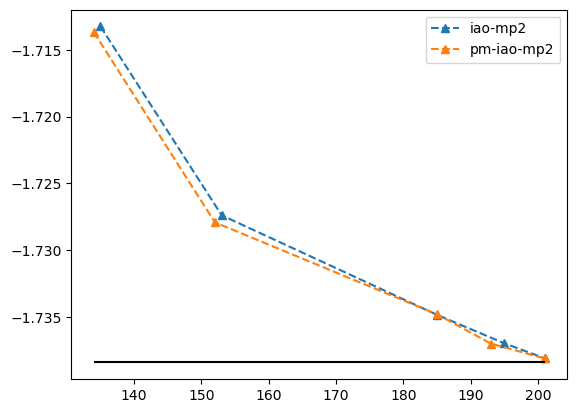

In [19]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="iao-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="pm-iao-mp2")
plt.hlines(emp2_ref, xmin=min(las2), xmax=max(las1), colors='k')
plt.legend()
plt.show()

In [48]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc=None)

las3 = np.zeros(len(threshs))
elnomp3 = np.zeros(len(threshs))
elnocc3 = np.zeros(len(threshs))
elnoqmc3 = np.zeros(len(threshs))
elnoqmc_err3 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las3[i], elnomp3[i], elnocc3[i], elnoqmc3[i], elnoqmc_err3[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )


 ******* LNO-CALCULATION ******* 

LO occ span the occupied MO occ space - True.
MO occ span the occupied LO occ space - False.
LNO THRESHOLD = [0.001, 0.0001]


====================== unrestricted LNO-FRAGMENT 1/(7,7) =======================
Fragment Name Fe0
LO occ proj: 10 active | 5 standby | 18 orthogonal
LO occ proj: 6 active | 8 standby | 15 orthogonal
nfrozen occupied orbitals:  [22, 22]
nactive occupied orbitals:  [22, 18]
nactive virtual orbitals:   [86, 84]
nfrozen virtual orbitals:   [116, 122]

WARN: CCSD detected DF being used in the HF object. MO integrals are computed based on the DF 3-index tensors.
It's recommended to use dfccsd.CCSD for the DF-CCSD calculations

Init t2, MP2 energy = -0.852514980344698
LNO-Active Space Size     [108, 102]
LNO-MP2 Orbital Energy    -0.54102249
LNO-CCSD Orbital Energy   0.00000000
LNO-AFQMC Orbital Energy  0.00000 0.00000


====================== unrestricted LNO-FRAGMENT 2/(7,7) =======================
Fragment Name O1H2H16
LO occ pr

In [46]:
iao_coeff, frag_list, frag_name = iao_fragment(mf, frag_type='h2heavy', more_loc='boys')

las4 = np.zeros(len(threshs))
elnomp4 = np.zeros(len(threshs))
elnocc4 = np.zeros(len(threshs))
elnoqmc4 = np.zeros(len(threshs))
elnoqmc_err4 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
    las4[i], elnomp4[i], elnocc4[i], elnoqmc4[i], elnoqmc_err4[i] = \
        run_lno(mf,
                iao_coeff, 
                frag_list,
                frag_name,
                nfrozen = elements.chemcore(mol),
                lno_thresh = lno_thresh,
                qmc_options = options, 
                chol_cut = 1e-5, 
                target_qmc_err = 1e-3, 
                run_frag = None, 
                run_ccsd = False,
                run_qmc = False,
                )



******** <class 'pyscf.lo.boys.Boys'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
Set conv_tol_grad to 0.000316228
macro= 1  f(x)= 90.922898080384  delta_f= 90.9229  |g|= 3.81288  4 KF 20 Hx
macro= 2  f(x)= 89.429564601847  delta_f= -1.49333  |g|= 1.22815  4 KF 20 Hx
macro= 3  f(x)= 88.530140719339  delta_f= -0.899424  |g|= 0.618039  4 KF 20 Hx
macro= 4  f(x)= 87.845834947712  delta_f= -0.684306  |g|= 0.647528  4 KF 20 Hx
macro= 5  f(x)= 87.105192991585  delta_f= -0.740642  |g|= 0.675576  4 KF 20 Hx
macro= 6  f(x)= 86.786523015409  delta_f= -0.31867  |g|= 0.487664  4 KF 21 Hx
macro= 7  f(x)= 86.490833559738  delta_f= -0.295689  |g|= 0.280806  4 KF 22 Hx
macro= 8  f(x)= 86.244057863895  delta_f= -0.246776  |g|= 0.129891  4 KF 24 Hx
macro

[108. 160. 182. 219. 224. 235.]
[-1.76061922 -1.80166313 -1.82200553 -1.83193687 -1.83527373 -1.83688828]
[ 64. 105. 148. 165. 184. 221.]
[-1.76078965 -1.79632382 -1.82092982 -1.83155934 -1.83491449 -1.83683342]
[108. 160. 182. 219. 224. 235.]
[-1.76628381 -1.80483216 -1.82525055 -1.83349476 -1.83581797 -1.83707309]
[ 64. 105. 148. 165. 184. 221.]
[-1.76624487 -1.79887084 -1.82435496 -1.83285926 -1.83532036 -1.83703125]


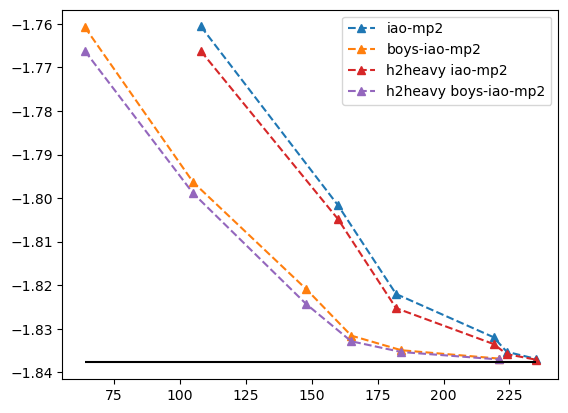

In [49]:
print(las1)
print(elnomp1)
print(las2)
print(elnomp2)
print(las3)
print(elnomp3)
print(las4)
print(elnomp4)
from matplotlib import pyplot as plt
plt.plot(las1, elnomp1, "^--", color="C0", label="iao-mp2")
plt.plot(las2, elnomp2, "^--", color="C1", label="boys-iao-mp2")
plt.plot(las3, elnomp3, "^--", color="C3", label="h2heavy iao-mp2")
plt.plot(las4, elnomp4, "^--", color="C4", label="h2heavy boys-iao-mp2")
plt.hlines(emp2_ref, xmin=min(las2), xmax=max(las1), colors='k')
plt.legend()
plt.show()